# Schnakenberg 1D Demo

In this notebook, we simulate the Schnakenberg reaction–diffusion system in one spatial dimension using the AB2–AM2 scheme.

The aim is to visualise how diffusion-driven instability leads to the emergence of spatial structure from a small perturbation of the homogeneous steady state.

We examine how the final pattern depends on:
- the domain length $L$,
- the diffusion ratio $d$,
- and the initial perturbation.

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../.."))

import numpy as np

from src.solvers import AB2AM2Solver1D
from src.models import SchnakenbergModel
from src.visualiser import plot_1D_single, plot_1D_grid

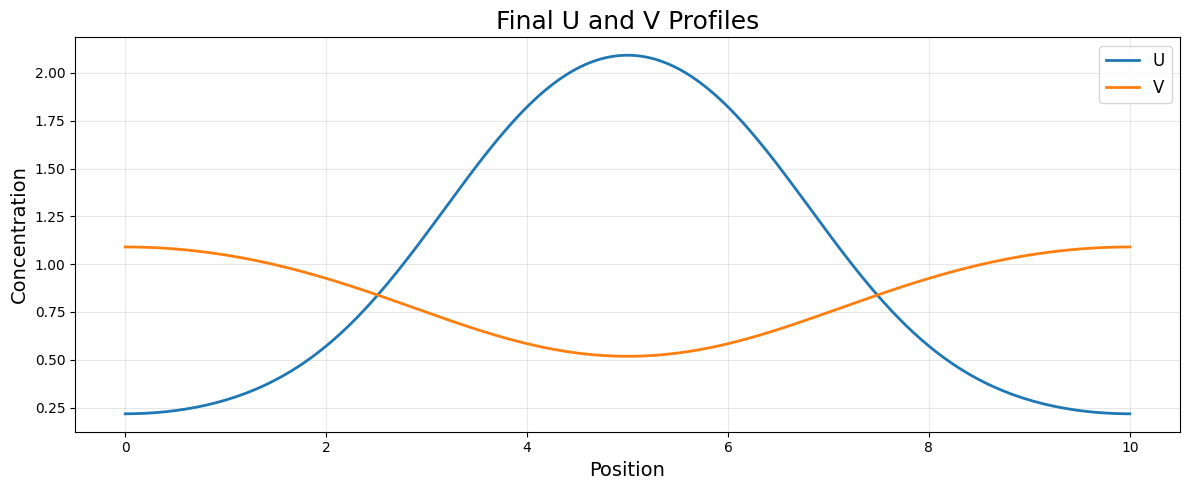

In [3]:
params = {
    "a": 0.1,
    "b": 0.9,
    "gamma": 2.0,
    "d": 20.0
}

solver = AB2AM2Solver1D(
    model=SchnakenbergModel,
    params=params,
    Lx=10,
    N=200,
    T=100,
    dt=0.05
)

t, U, V, x = solver.run(euler_step="y")

plot_1D_single(x, U[-1], V[-1])

## Parameter sweep

We now vary the domain length $L$ and diffusion ratio $d$ to observe how the spatial pattern depends on these parameters.

Larger domains allow more spatial modes, while higher diffusion ratios promote instability.

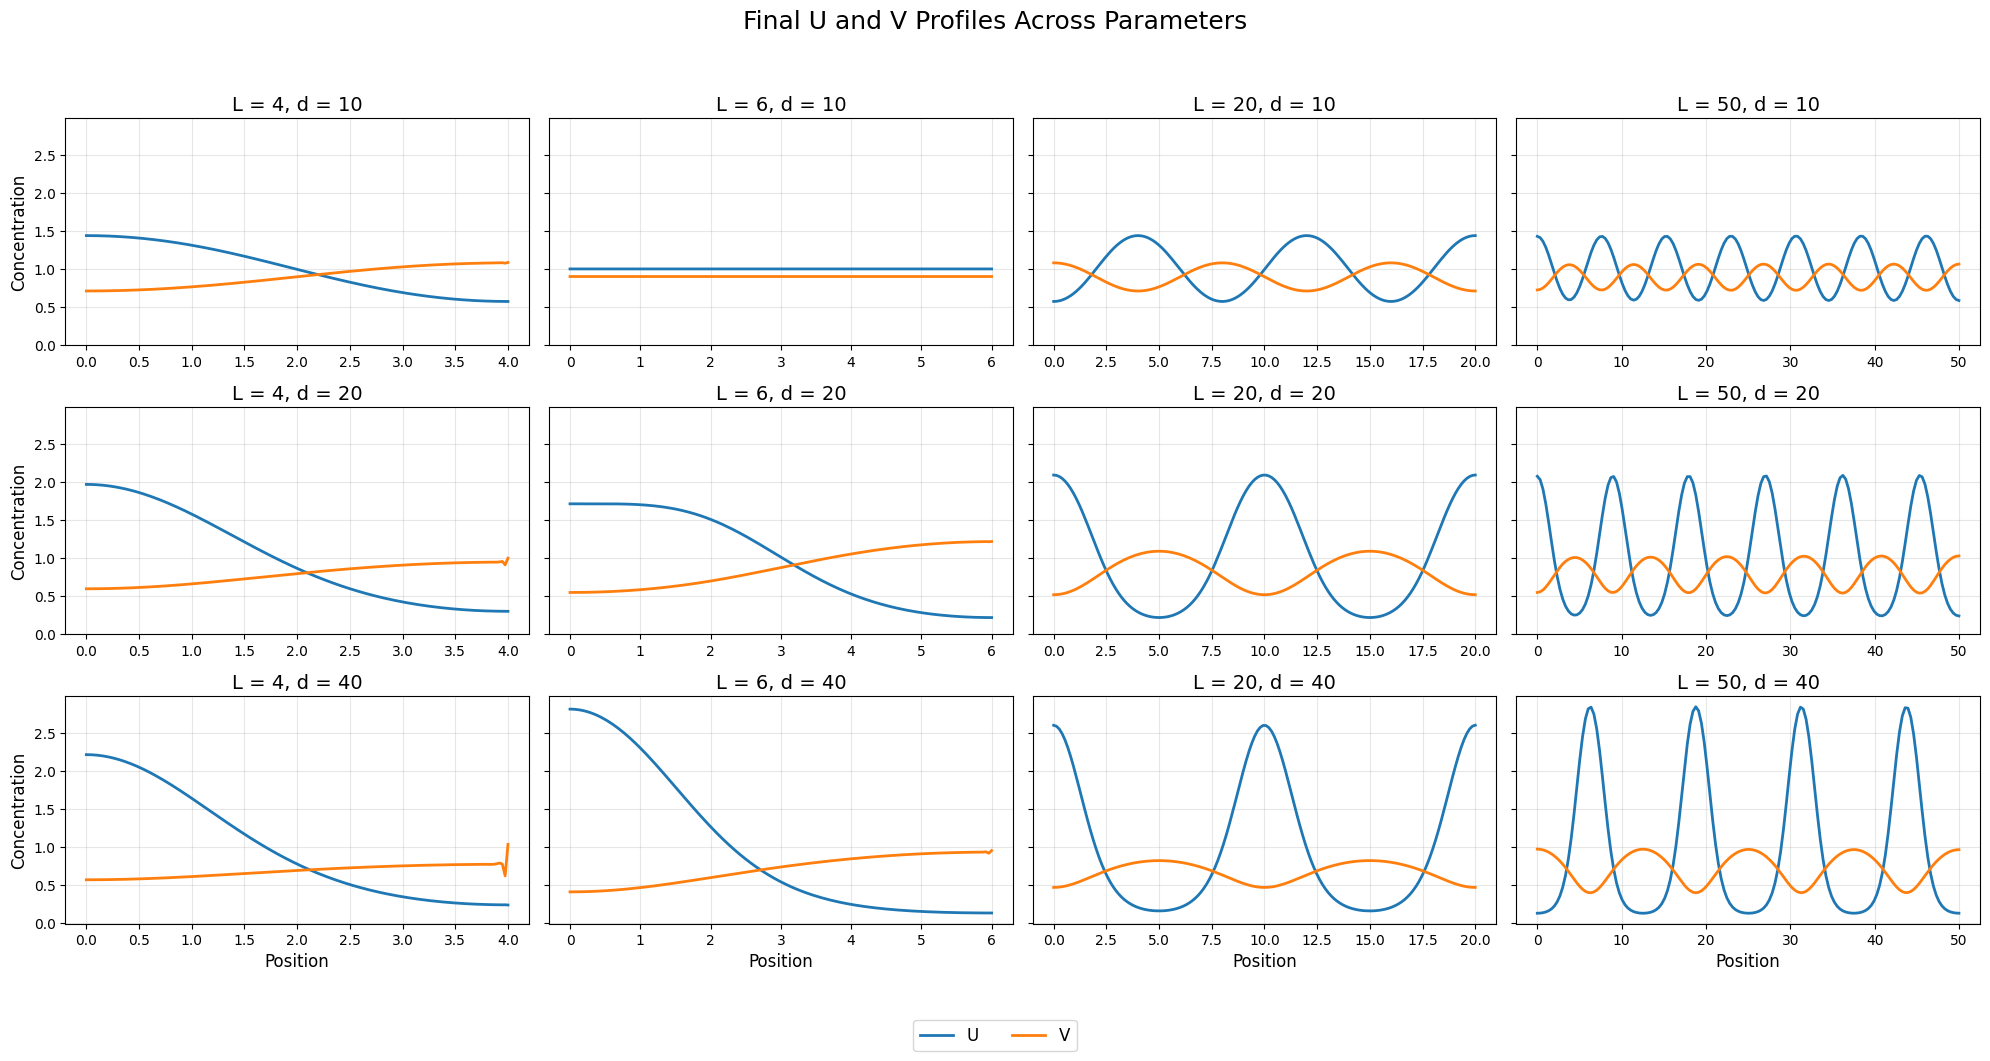

In [4]:
L_vals = [4, 6, 20, 50]
d_vals = [10, 20, 40]

params = {
    "a": 0.1,
    "b": 0.9,
    "gamma": 2.0,
    "d": None
}

results = {}

for d in d_vals:
    for L in L_vals:
        params["d"] = d

        solver = AB2AM2Solver1D(
            model=SchnakenbergModel,
            params=params,
            Lx=L,
            N=150,
            T=100,
            dt=0.05
        )

        t, U, V, x = solver.run(euler_step="y")

        results[(d, L)] = (x, U[-1], V[-1])

plot_1D_grid(results, L_vals, d_vals)

## Conclusion

The simulations confirm the theoretical predictions from the analysis notebook.

For sufficiently large diffusion ratio $d$, spatially heterogeneous steady states emerge from small perturbations of the homogeneous solution. The number and structure of these patterns depend strongly on the domain length $L$, which determines the admissible spatial modes.

This provides a direct numerical realisation of diffusion-driven instability in the Schnakenberg system.